<a href="https://colab.research.google.com/github/narendrapatel6321-dotcom/movie_recommendation_system/blob/main/Neural_Recommender_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Collaborative Filtering - MovieLens 1M

This project implements and compares three recommendation models — **Matrix Factorization (MF)**, **Multi-Layer Perceptron (MLP)**, and **Neural Matrix Factorization (NeuMF)** — on the MovieLens 1M dataset.

The models progressively increase the expressiveness of user–item interaction modeling:

**MF -> MLP -> NeuMF**

Models are evaluated using **Hit Rate@10 (HR@10)** and **NDCG@10** under a leave-one-out ranking protocol.

In [1]:
!git clone https://github.com/narendrapatel6321-dotcom/movie_recommendation_system.git
%cd movie_recommendation_system
!pip install -q -r requirements.txt

Cloning into 'movie_recommendation_system'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 107 (delta 32), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 48.25 KiB | 5.36 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/movie_recommendation_system


## Imports

In [2]:
import logging
import os
from typing import Dict, List
from pathlib import Path

import tensorflow as tf

from src.data import MovieLensDataLoader, create_datasets
from src.evaluate import RankingEvaluator
from src.models import create_model
from src.train import RecommenderTrainer
from src.utils import (
    plot_comparison_bar,
    plot_training_history,
    save_model,
    set_seed,
)

## Experimental Setup

All models use the same dataset split, negative-sampling protocol, evaluation metrics, and maximum training budget to keep the comparison consistent.

Model-specific hyperparameters are configured independently so that each architecture has a reasonable opportunity to perform well.

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
    datefmt="%H:%M:%S",
)

logger = logging.getLogger(__name__)


COMMON_CONFIG = {
    "data_dir": "data/ml-1m",
    "batch_size": 4096,
    "num_negatives": 4,
    "eval_negatives": 99,
    "patience": 5,
    "seed": 42,
    "eval_k": 10,
    "eval_batch_size": 256,
    "results_dir": "results",
}

MF_CONFIG = {
    "embed_dim": 64,
    "epochs": 30,
    "lr": 1e-3,
}

MLP_CONFIG = {
    "embed_dim": 32,
    "epochs": 50,
    "layers": (64, 32, 16),
    "dropout": 0.2,
    "lr": 1e-3,
}

NEUMF_CONFIG = {
    "mf_dim": 32,
    "mlp_embed": 32,
    "epochs": 30,
    "layers": (64, 32, 16),
    "dropout": 0.2,
    "lr" : 5e-4,
}

set_seed(COMMON_CONFIG["seed"])

gpus = tf.config.list_physical_devices("GPU")
logger.info(
    "TensorFlow %s | GPUs available: %d",
    tf.__version__,
    len(gpus),
)

if not gpus:
    logger.warning(
        "No GPU detected — training will run on CPU. "
        "In Colab: Runtime > Change runtime type > GPU."
    )

## Dataset

The experiments use the **MovieLens 1M** dataset.

User and movie IDs are remapped to contiguous zero-based indices so they can be used directly with embedding layers.

For each user, interactions are ordered chronologically:

- the most recent interaction is held out for testing,
- the second-most recent interaction is used for validation,
- all earlier interactions are used for training.

In [4]:
data_dir = Path(COMMON_CONFIG["data_dir"])
data_root_dir = data_dir.parent
ratings_path = data_dir / "ratings.dat"
zip_file_path = data_root_dir / "ml-1m.zip"

data_root_dir.mkdir(parents=True, exist_ok=True)

if not ratings_path.exists():
    logger.info(
        "MovieLens 1M dataset not found at '%s'. Downloading and extracting...",
        ratings_path,
    )

    ml_1m_url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"

    logger.info("Downloading MovieLens 1M...")
    !wget -q -P {data_root_dir} {ml_1m_url}

    logger.info("Extracting MovieLens 1M...")
    !unzip -q {zip_file_path} -d {data_root_dir}

    if zip_file_path.exists():
        zip_file_path.unlink()

    logger.info("MovieLens 1M dataset setup complete.")
else:
    logger.info("MovieLens 1M dataset already exists at '%s'.", ratings_path)

logger.info("Loading MovieLens 1M from '%s'...", data_dir)

data = MovieLensDataLoader(
    data_dir=str(data_dir)
).load()

### Dataset Summary

The loader returns the processed interaction data together with the number of users, number of items, and the train/validation/test partitions.

In [5]:
import pandas as pd

dataset_summary = pd.DataFrame(
    {
        "Statistic": [
            "Users",
            "Items",
            "Total interactions",
            "Training interactions",
            "Validation interactions",
            "Test interactions",
        ],
        "Value": [
            data["n_users"],
            data["n_items"],
            len(data["train"]) + len(data["val"]) + len(data["test"]),
            len(data["train"]),
            len(data["val"]),
            len(data["test"]),
        ],
    }
)

dataset_summary

,Statistic,Value
0,Users,6040
1,Items,3706
2,Total interactions,1000209
3,Training interactions,988129
4,Validation interactions,6040
5,Test interactions,6040


## Evaluation Protocol

The models are evaluated as a **ranking problem** rather than by classification accuracy.

For each user, the held-out positive interaction is evaluated against **99 randomly sampled items that the user has not interacted with**. The model scores all 100 candidates and ranks them by predicted interaction score.

Two ranking metrics are reported:

- **HR@10 (Hit Rate@10):** measures whether the held-out positive item appears among the top 10 ranked candidates.
- **NDCG@10:** rewards placing the held-out positive item higher in the top-10 ranking.

The same evaluation protocol is used for MF, MLP, and NeuMF so their results remain directly comparable.

In [6]:
evaluation_summary = pd.DataFrame(
    {
        "Setting": [
            "Evaluation candidates per user",
            "Ranking cutoff (K)",
            "Metrics",
        ],
        "Value": [
            1 + COMMON_CONFIG["eval_negatives"],
            COMMON_CONFIG["eval_k"],
            f"HR@{COMMON_CONFIG['eval_k']}, NDCG@{COMMON_CONFIG['eval_k']}",
        ],
    }
)

evaluation_summary

,Setting,Value
0,Evaluation candidates per user,100
1,Ranking cutoff (K),10
2,Metrics,"HR@10, NDCG@10"


## Matrix Factorization

Matrix Factorization provides the simplest baseline for the experiment.

Each user and item is represented by a learned embedding vector. The interaction score is computed from their dot product, with additional user and item bias terms:

$$
\hat{y}_{ui}
=
\sigma(p_u^\top q_i + b_u + b_i)
$$

This gives us a linear interaction model against which the more expressive MLP and NeuMF architectures can be compared.

In [7]:
histories: Dict[str, Dict[str, List[float]]] = {}
results: Dict[str, Dict[str, float]] = {}

In [8]:
train_ds, val_ds, test_ds = create_datasets(
    data,
    num_negatives=COMMON_CONFIG["num_negatives"],
    eval_negatives=COMMON_CONFIG["eval_negatives"],
    seed=COMMON_CONFIG["seed"],
)

In [9]:
mf_model = create_model(
    model_name="MF",
    n_users=data["n_users"],
    n_items=data["n_items"],
    config=MF_CONFIG,
)

dummy_user = tf.zeros((1,), dtype=tf.int64)
dummy_item = tf.zeros((1,), dtype=tf.int64)

_ = mf_model((dummy_user, dummy_item), training=False)

mf_model.summary()

Model: "matrix_factorization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ user_emb (Embedding)            │ (1, 64)                │       386,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ item_emb (Embedding)            │ (1, 64)                │       237,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ user_bias (Embedding)           │ (1, 1)                 │         6,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ item_bias (Embedding)           │ (1, 1)                 │         3,706 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 633,490 (2.42 MB)

 Trainable params: 633,490 (2.42 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
mf_trainer = RecommenderTrainer(
    model=mf_model,
    lr=MF_CONFIG["lr"],
    epochs=MF_CONFIG["epochs"],
    batch_size=COMMON_CONFIG["batch_size"],
    patience=COMMON_CONFIG["patience"],
    eval_k=COMMON_CONFIG["eval_k"],
    eval_batch_size=COMMON_CONFIG["eval_batch_size"],
)

mf_model, mf_history = mf_trainer.fit(
    train_dataset=train_ds,
    val_dataset=val_ds,
)

Epoch 1/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - loss: 0.4939 - val_hr: 0.4240 - val_ndcg: 0.2322
Epoch 2/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.3803 - val_hr: 0.4227 - val_ndcg: 0.2321
Epoch 3/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - loss: 0.3585 - val_hr: 0.4315 - val_ndcg: 0.2372
Epoch 4/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 0.3467 - val_hr: 0.4690 - val_ndcg: 0.2588
Epoch 5/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.3170 - val_hr: 0.5286 - val_ndcg: 0.2922
Epoch 6/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.2934 - val_hr: 0.5740 - val_ndcg: 0.3223
Epoch 7/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.2787 - val_hr: 0.6079 - val_ndcg: 0.3465
Epoch 8/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.2661 - val_hr: 0.6305 - val_ndcg: 0.3626
Epoch 9/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 0.2577 - val_hr: 0.6472 - val_ndcg: 0.3754
Epoch 10/30
1207/1207 ━━━━━━━━━━━━━━━

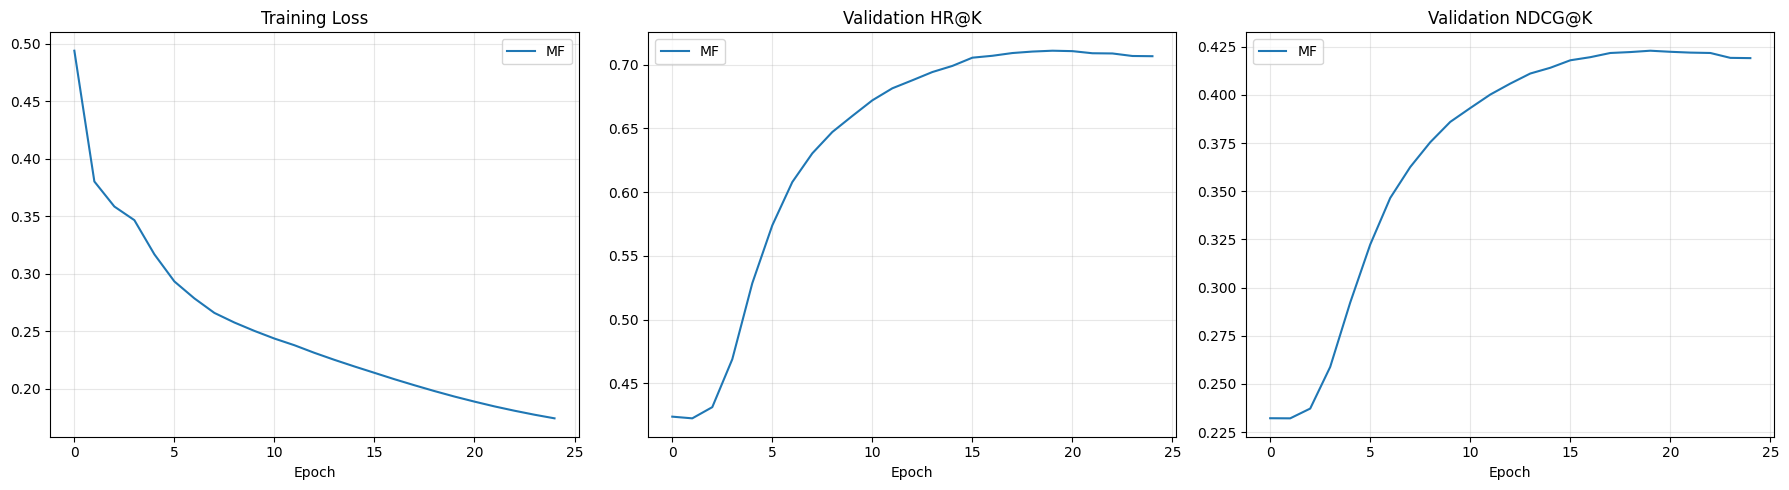

In [11]:
plot_training_history({
    "MF": mf_history
})

In [12]:
mf_evaluator = RankingEvaluator(
    k=COMMON_CONFIG["eval_k"],
    eval_batch_size=COMMON_CONFIG["eval_batch_size"],
)

mf_metrics = mf_evaluator.evaluate(
    model=mf_model,
    eval_dataset=test_ds,
)

results["MF"] = mf_metrics
histories["MF"] = mf_history

In [13]:
mf_results = pd.DataFrame(
    {
        "Metric": ["HR@10", "NDCG@10"],
        "Score": [
            mf_metrics["hr@10"],
            mf_metrics["ndcg@10"],
        ],
    }
)

mf_results

,Metric,Score
0,HR@10,0.674669
1,NDCG@10,0.401046


In [14]:
save_model(
    mf_model,
    COMMON_CONFIG["results_dir"],
    "mf",
)

### MF — Interpretation

The model achieved the following ranking performance on the held-out test interactions:

- **HR@10:** ...
- **NDCG@10:** ...

The result provides the baseline against which the MLP and NeuMF architectures will be compared.

## Multi-Layer Perceptron

The MLP model replaces the dot-product interaction used by Matrix Factorization with a learned nonlinear interaction function.

User and item embeddings are concatenated and passed through a stack of fully connected layers before producing the final interaction score.

Unlike MF, the MLP architecture can learn more complex user–item interaction patterns.

In [15]:
mlp_model = create_model(
    model_name="MLP",
    n_users=data["n_users"],
    n_items=data["n_items"],
    config=MLP_CONFIG,
)

_ = mlp_model(
    (
        tf.zeros((1,), dtype=tf.int64),
        tf.zeros((1,), dtype=tf.int64),
    ),
    training=False,
)

mlp_model.summary()

Model: "mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ user_emb (Embedding)            │ (1, 32)                │       193,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ item_emb (Embedding)            │ (1, 32)                │       118,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 32)                │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 16)                │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1, 1)                 │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,657 (1.22 MB)

 Trainable params: 318,657 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
mlp_trainer = RecommenderTrainer(
    model=mlp_model,
    lr=MLP_CONFIG["lr"],
    epochs=MLP_CONFIG["epochs"],
    batch_size=COMMON_CONFIG["batch_size"],
    patience=COMMON_CONFIG["patience"],
    eval_k=COMMON_CONFIG["eval_k"],
    eval_batch_size=COMMON_CONFIG["eval_batch_size"],
)

mlp_model, mlp_history = mlp_trainer.fit(
    train_dataset=train_ds,
    val_dataset=val_ds,
)

Epoch 1/50
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - loss: 0.3751 - val_hr: 0.4224 - val_ndcg: 0.2327
Epoch 2/50
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.3500 - val_hr: 0.4621 - val_ndcg: 0.2520
Epoch 3/50
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.3307 - val_hr: 0.5076 - val_ndcg: 0.2793
Epoch 4/50
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 0.3169 - val_hr: 0.5325 - val_ndcg: 0.2969
Epoch 5/50
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.3071 - val_hr: 0.5503 - val_ndcg: 0.3062
Epoch 6/50
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 0.2990 - val_hr: 0.5685 - val_ndcg: 0.3170
Epoch 7/50
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - loss: 0.2917 - val_hr: 0.5740 - val_ndcg: 0.3221
Epoch 8/50
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - loss: 0.2854 - val_hr: 0.5877 - val_ndcg: 0.3315
Epoch 9/50
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.2806 - val_hr: 0.6070 - val_ndcg: 0.3412
Epoch 10/50
1207/1207 ━━━━━━━━━━━━━━━

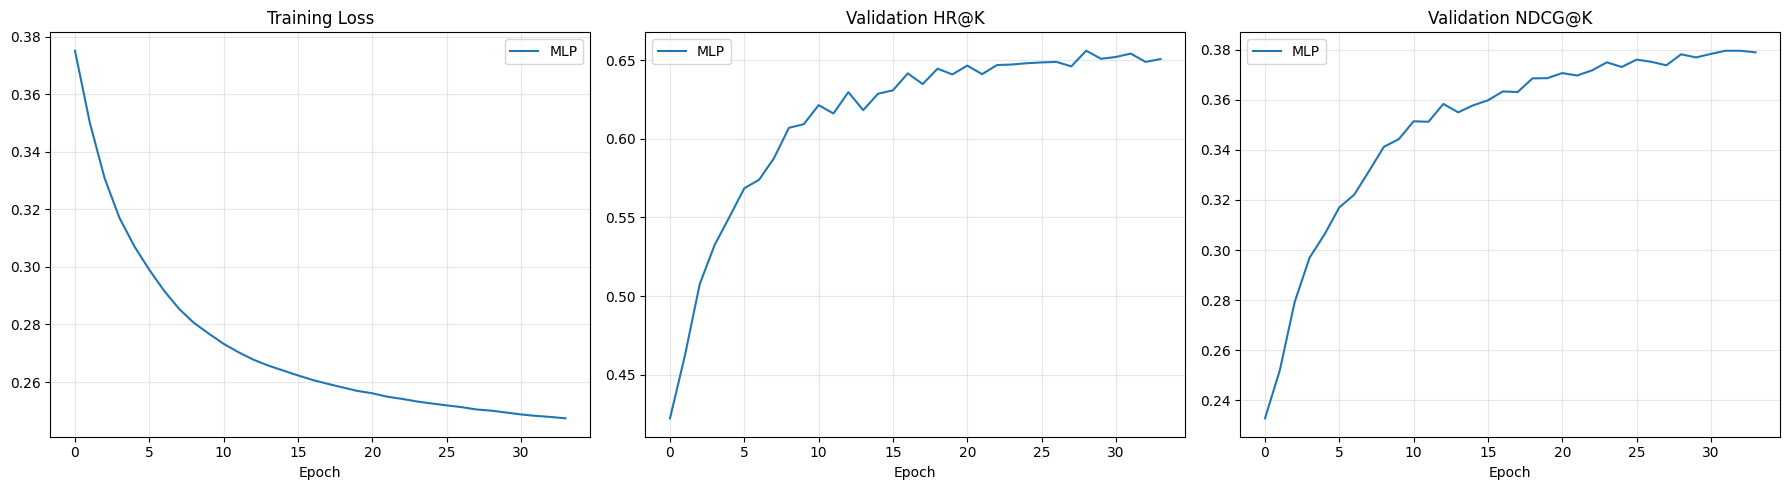

In [17]:
plot_training_history({
    "MLP": mlp_history
})

In [18]:
mlp_evaluator = RankingEvaluator(
    k=COMMON_CONFIG["eval_k"],
    eval_batch_size=COMMON_CONFIG["eval_batch_size"],
)

mlp_metrics = mlp_evaluator.evaluate(
    model=mlp_model,
    eval_dataset=test_ds,
)

In [19]:
mlp_results = pd.DataFrame(
    {
        "Metric": ["HR@10", "NDCG@10"],
        "Score": [
            mlp_metrics["hr@10"],
            mlp_metrics["ndcg@10"],
        ],
    }
)

mlp_results

,Metric,Score
0,HR@10,0.608278
1,NDCG@10,0.352158


In [20]:
results["MLP"] = mlp_metrics
histories["MLP"] = mlp_history

save_model(
    mlp_model,
    COMMON_CONFIG["results_dir"],
    "mlp",
)

## Neural Matrix Factorization

NeuMF combines the complementary strengths of Matrix Factorization and the MLP interaction model.

The GMF branch captures multiplicative user–item interactions, while the MLP branch learns nonlinear interaction patterns. Their representations are then combined before the final prediction layer.

This gives NeuMF the most expressive architecture among the three models in this experiment.

In [21]:
neumf_model = create_model(
    model_name="NeuMF",
    n_users=data["n_users"],
    n_items=data["n_items"],
    config=NEUMF_CONFIG,
)

_ = neumf_model(
    (
        tf.zeros((1,), dtype=tf.int64),
        tf.zeros((1,), dtype=tf.int64),
    ),
    training=False,
)

neumf_model.summary()

Model: "neu_mf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mf_user (Embedding)             │ (1, 32)                │       193,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mf_item (Embedding)             │ (1, 32)                │       118,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_user (Embedding)            │ (1, 32)                │       193,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_item (Embedding)            │ (1, 32)                │       118,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 32)                │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (1, 16)                │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (1, 1)                 │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 630,561 (2.41 MB)

 Trainable params: 630,561 (2.41 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
neumf_trainer = RecommenderTrainer(
    model=neumf_model,
    lr=NEUMF_CONFIG["lr"],
    epochs=NEUMF_CONFIG["epochs"],
    batch_size=COMMON_CONFIG["batch_size"],
    patience=COMMON_CONFIG["patience"],
    eval_k=COMMON_CONFIG["eval_k"],
    eval_batch_size=COMMON_CONFIG["eval_batch_size"],
)

neumf_model, neumf_history = neumf_trainer.fit(
    train_dataset=train_ds,
    val_dataset=val_ds,
)

Epoch 1/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - loss: 0.3830 - val_hr: 0.4288 - val_ndcg: 0.2355
Epoch 2/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.3444 - val_hr: 0.4805 - val_ndcg: 0.2649
Epoch 3/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 0.3151 - val_hr: 0.5455 - val_ndcg: 0.3044
Epoch 4/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - loss: 0.2926 - val_hr: 0.5940 - val_ndcg: 0.3358
Epoch 5/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.2777 - val_hr: 0.6195 - val_ndcg: 0.3544
Epoch 6/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.2682 - val_hr: 0.6346 - val_ndcg: 0.3657
Epoch 7/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.2609 - val_hr: 0.6467 - val_ndcg: 0.3761
Epoch 8/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - loss: 0.2546 - val_hr: 0.6523 - val_ndcg: 0.3829
Epoch 9/30
1207/1207 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.2487 - val_hr: 0.6623 - val_ndcg: 0.3887
Epoch 10/30
1207/1207 ━━━━━━━━━━━━━━━

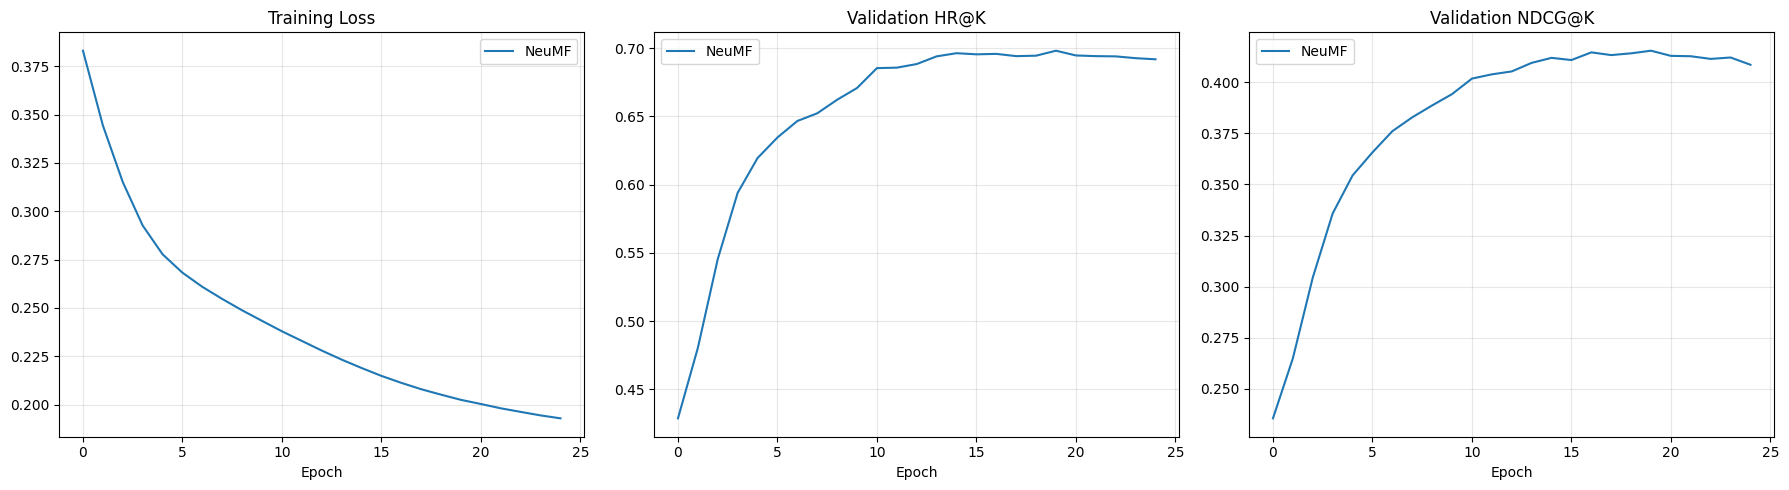

In [23]:
plot_training_history({
    "NeuMF": neumf_history
})

In [24]:
neumf_evaluator = RankingEvaluator(
    k=COMMON_CONFIG["eval_k"],
    eval_batch_size=COMMON_CONFIG["eval_batch_size"],
)

neumf_metrics = neumf_evaluator.evaluate(
    model=neumf_model,
    eval_dataset=test_ds,
)

In [25]:
neumf_results = pd.DataFrame(
    {
        "Metric": ["HR@10", "NDCG@10"],
        "Score": [
            neumf_metrics["hr@10"],
            neumf_metrics["ndcg@10"],
        ],
    }
)

neumf_results

,Metric,Score
0,HR@10,0.656126
1,NDCG@10,0.385180


In [26]:
results["NeuMF"] = neumf_metrics
histories["NeuMF"] = neumf_history

save_model(
    neumf_model,
    COMMON_CONFIG["results_dir"],
    "neumf",
)

## Final Model Comparison

The three recommendation models are compared using Hit Rate@10 and NDCG@10 on the held-out test set.

Both metrics evaluate the quality of the top-10 recommendations, with NDCG@10 additionally accounting for the position of the relevant item within the ranking.

In [27]:
final_results = pd.DataFrame(results).T

final_results = final_results[
    ["hr@10", "ndcg@10"]
].rename(
    columns={
        "hr@10": "HR@10",
        "ndcg@10": "NDCG@10",
    }
)

final_results.sort_values("HR@10", ascending=False)

,HR@10,NDCG@10
MF,0.674669,0.401046
NeuMF,0.656126,0.385180
MLP,0.608278,0.352158


<Axes: title={'center': 'Model Performance on Test Set'}>

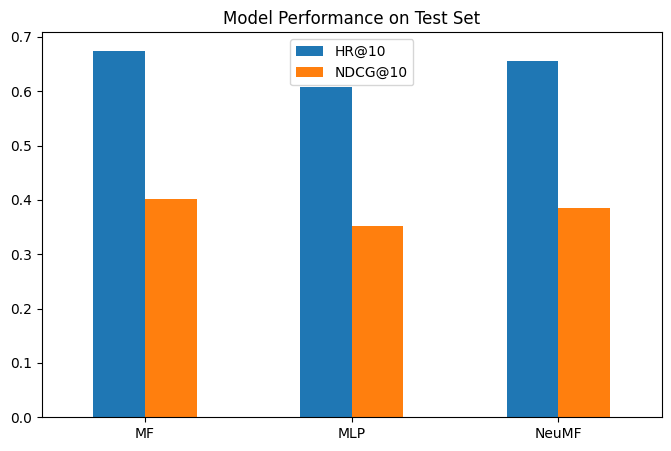

In [28]:
final_results.plot(
    kind="bar",
    figsize=(8, 5),
    rot=0,
    title="Model Performance on Test Set",
)

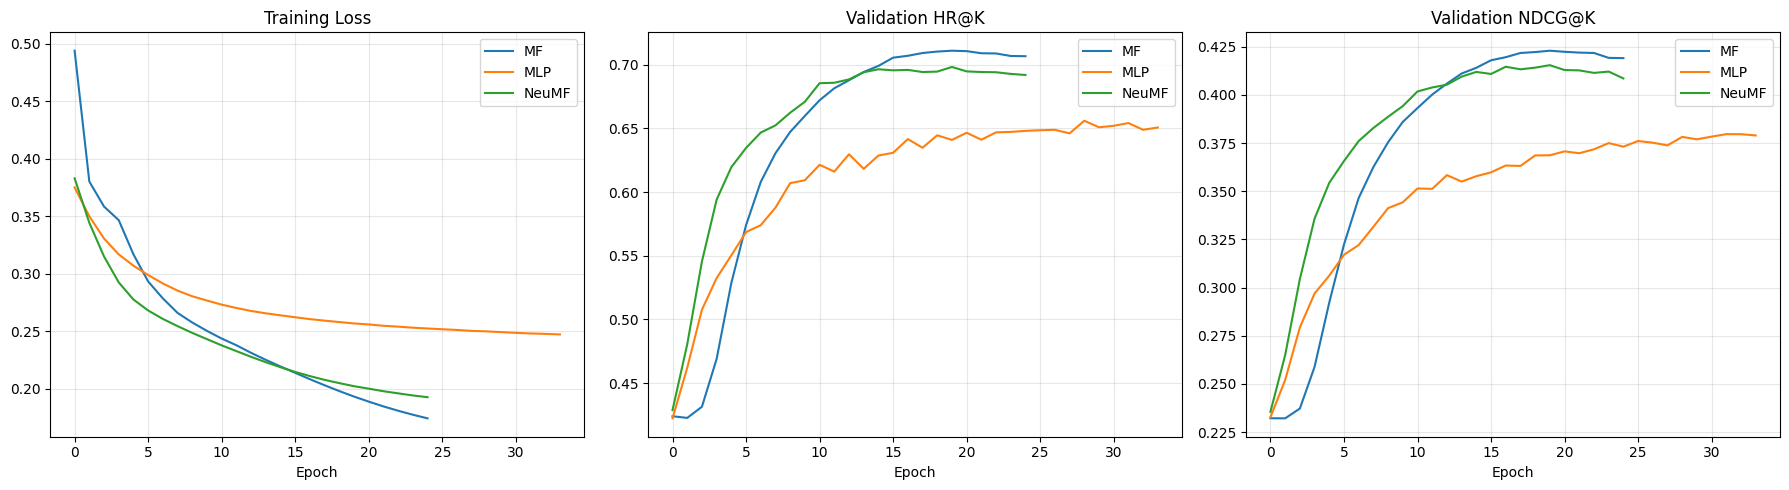

In [29]:
plot_training_history(histories)

### Training Behaviour

The models exhibit different convergence patterns. MF reaches its best validation ranking performance relatively early, while MLP benefits from a longer training budget. NeuMF converges earlier than MLP and achieves stronger ranking performance than the standalone MLP branch.

Early stopping is based on validation HR@10, with the best weights restored before final evaluation.

## Discussion

Matrix Factorization achieves the strongest overall ranking performance among the evaluated models.

The MLP model, despite having greater nonlinear modeling capacity, performs worse than the simpler MF baseline. This suggests that the additional flexibility of the MLP does not translate into better collaborative filtering performance for this dataset under the current training setup.

NeuMF improves substantially over the standalone MLP by combining multiplicative and nonlinear interaction branches, but it still does not outperform MF.

This result highlights an important practical point: increasing model complexity does not necessarily improve recommendation quality. A simpler model with a suitable inductive bias can outperform more expressive architectures.

## Conclusion

Three neural collaborative filtering approaches were evaluated under the same temporal train/validation/test protocol and ranking-based evaluation framework.

MF achieved the strongest performance on the held-out test set, while NeuMF provided an improvement over the standalone MLP model but remained below MF.

The experiments demonstrate the importance of comparing model complexity against actual ranking performance rather than assuming that a more expressive architecture will necessarily produce better recommendations.